In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

csv_path = '/Users/nehal/Downloads/Student Social Media And Mental Health Impact.csv'
df = pd.read_csv(csv_path)


In [3]:
# Looking for columns
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


#EDA

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

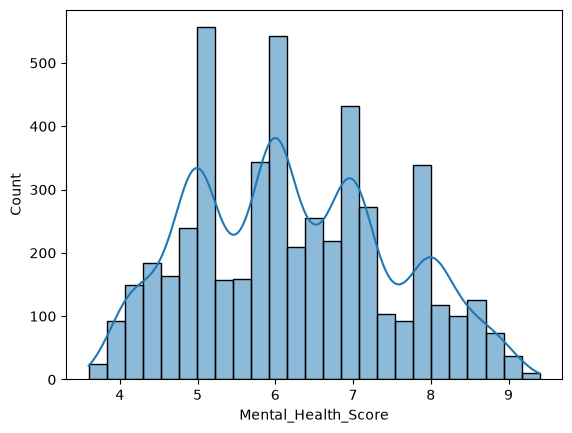

In [9]:
# Distribution of target = 'Mental Health Score'
sns.histplot(x='Mental_Health_Score', kde=True, data=df)


<Axes: >

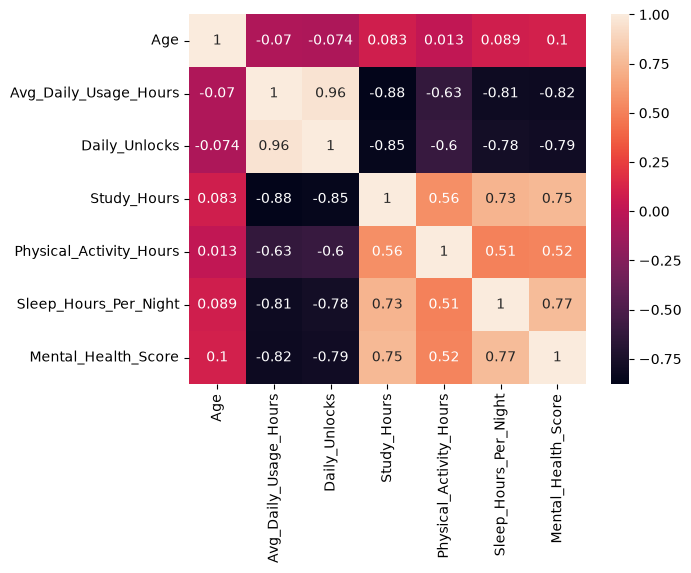

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [11]:
df['Stress_Level'].unique()

<StringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

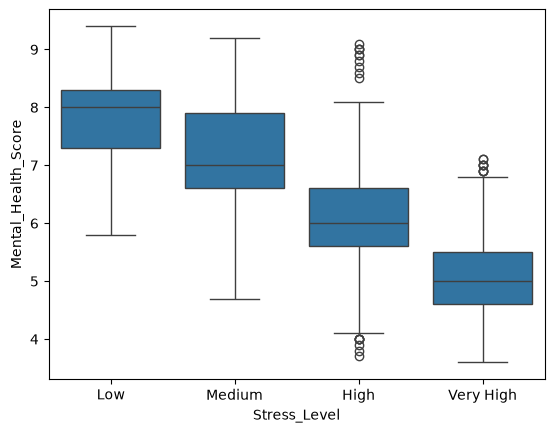

In [12]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

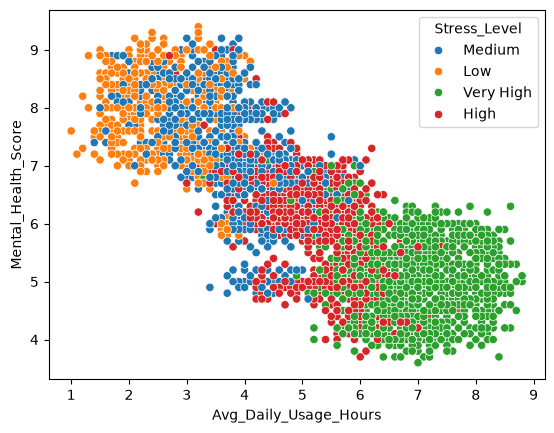

In [13]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df, hue='Stress_Level')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

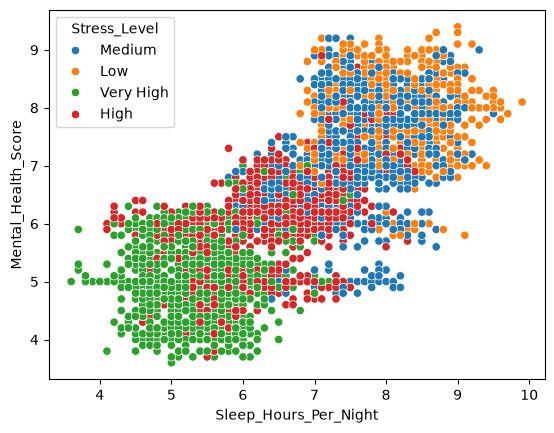

In [14]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df, hue='Stress_Level')

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

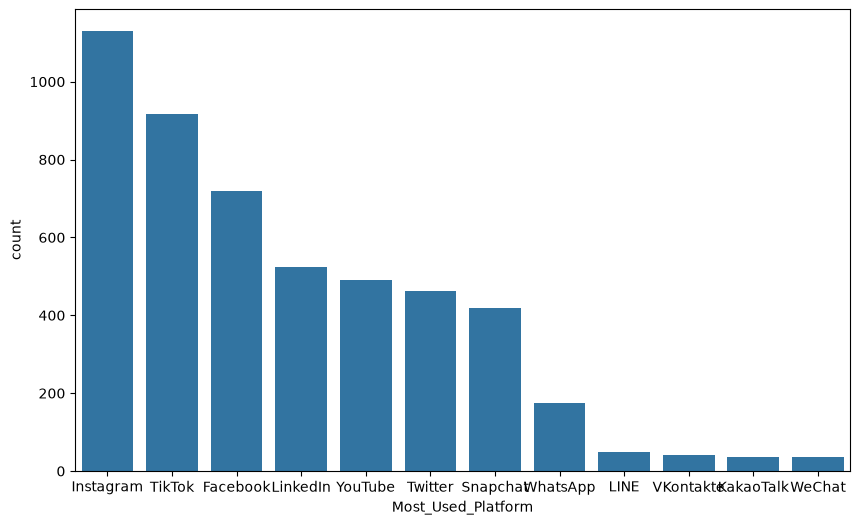

In [15]:
platform_counts = df['Most_Used_Platform'].value_counts()
plt.figure(figsize=(10, 6))
sns.countplot(x='Most_Used_Platform', data=df, order=platform_counts.index)

In [16]:
# Checking for outliers using IQR method
num_features = df.select_dtypes(include = 'number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# Data Cleaning

In [17]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [18]:
df = df.drop_duplicates()

In [19]:
# Converting unrealistic values to realistic values
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)


In [20]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [21]:
num_columns = df.select_dtypes(include='number')
num_columns

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [22]:
num_columns = df.select_dtypes(include='number')
num_columns.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

# Feature Engineering


In [39]:
top_countries = df['Country'].value_counts().index[:10].to_list()
top_countries


['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [24]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [25]:
df['Country'].apply(group_countries)

0        Other
1        Other
2       Canada
3        Other
4        Other
         ...  
4995     Other
4996     Other
4997     India
4998     Other
4999     Other
Name: Country, Length: 4998, dtype: str

In [26]:
df['grouped_countries'] = df['Country'].apply(group_countries)

In [27]:
df['grouped_countries'].value_counts()

grouped_countries
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [28]:
from sklearn.model_selection import train_test_split
skewed_columns = ['Study_Hours'] # Log Transformation
other_columns = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Physical_Activity_Hours', 'Daily_Unlocks'] # Standard Scaler
ordinal_columns = ['Stress_Level'] # Ordinal Encoding
normal_columns = ['Gender', 'Academic_Level', 'Most_Used_Platform', 'grouped_countries', 'Purpose_Of_Use'] # One Hot Encoding

feature_column = skewed_columns + other_columns + ordinal_columns + normal_columns
X = df[feature_column]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#1. Skewed Features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler())])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())])

#3. Ordinal Features
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))])

#4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers=[
    ('skew', skew_pipeline, skewed_columns),
    ('plain_numeric', plain_numeric_pipeline, other_columns),
    ('ordinal', ordinal_pipeline, ordinal_columns),
    ('normal', nominal_pipeline, normal_columns)])

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
lr_pipeline = Pipeline(steps=[
   ('preprocessor', preprocessor),
   ('regressor', LinearRegression())])

lr_pipeline.fit(X_train, y_train)
lr_predictions = lr_pipeline.predict(X_test)
lr_predictions_train = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_predictions)
lr_r2_training = r2_score(y_train, lr_predictions_train)
lr_mae = mean_absolute_error(y_test, lr_predictions)

print(f"Accuracy of training: {lr_r2_training}")
print(f"Accuracy of testing: {lr_r2_testing}")
print(f"Mean Absolute Error: {lr_mae}")

Accuracy of training: 0.7236771199387538
Accuracy of testing: 0.7397944617433021
Mean Absolute Error: 0.5361775634720183


In [31]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random_forest', RandomForestRegressor(random_state=42))])

rf_pipeline.fit(X_train, y_train)
rf_predictions = rf_pipeline.predict(X_test)
rf_predictions_training = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_predictions)
rf_r2_training = r2_score(y_train, rf_predictions_training)
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(f"Accuracy of training: {rf_r2_training}")
print(f"Accuracy of testing: {rf_r2_testing}")
print(f"Mean Absolute Error: {rf_mae}")



Accuracy of training: 0.9808649125098369
Accuracy of testing: 0.8771696681020422
Mean Absolute Error: 0.3482911666666667


In [32]:
# Hyperparameter tuning for Random Forest Regressor
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'random_forest__n_estimators':       [100, 200, 300],
    'random_forest__max_depth':         [5, 10, 15],
    'random_forest__min_samples_split': [2, 5, 10],
    'random_forest__min_samples_leaf':  [1, 2, 4],
}
random_search = RandomizedSearchCV(
    estimator=rf_pipeline, 
    param_distributions=param_grid, 
    n_iter=15, 
    cv=5, 
    scoring='r2', 
    random_state=42,
    n_jobs=-1 # processor free
    )

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'random_forest__max_depth': [5, 10, ...], 'random_forest__min_samples_leaf': [1, 2, ...], 'random_forest__min_samples_split': [2, 5, ...], 'random_forest__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [33]:
random_search.best_params_

{'random_forest__n_estimators': 200,
 'random_forest__min_samples_split': 5,
 'random_forest__min_samples_leaf': 2,
 'random_forest__max_depth': 15}

In [34]:
rf_best_pipeline = random_search.best_estimator_
rf_best_predictions = rf_best_pipeline.predict(X_test)

print(f"R2 Score of random forest regressor after hyperparameter tuning: {r2_score(y_test, rf_best_predictions)}")
print(f"Mean Absolute Error of random forest regressor after hyperparameter tuning: {mean_absolute_error(y_test, rf_best_predictions)}")

R2 Score of random forest regressor after hyperparameter tuning: 0.8651132908913022
Mean Absolute Error of random forest regressor after hyperparameter tuning: 0.36890680149220406


In [35]:
# Model Evaluation
from sklearn.metrics import mean_squared_error
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions)) # RMSE for Linear Regression
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions)) # RMSE for Random Forest Regressor

# RMSE for tuned random forest regressor
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_best_predictions))
rf_tuned_predictions = random_search.best_estimator_.predict(X_test)
rf_tuned_training_predictions = random_search.best_estimator_.predict(X_train)
r2_tuned_training = r2_score(y_train, rf_tuned_training_predictions)
rf_tuned_r2 = r2_score(y_test, rf_tuned_predictions)
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_predictions)

# Dataframe to consolidate the results
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Tuned Random Forest Regressor'],
    'R2 Score (Training)': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'R2 Score (Testing)': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae]
})

print(results_df)

                           Model  R2 Score (Training)  R2 Score (Testing)  \
0              Linear Regression             0.723677            0.739794   
1        Random Forest Regressor             0.980865            0.877170   
2  Tuned Random Forest Regressor             0.954698            0.865113   

       RMSE       MAE  
0  0.676032  0.536178  
1  0.464474  0.348291  
2  0.486736  0.368907  


In [36]:
import joblib
joblib.dump(rf_pipeline, 'mental_health_model.pkl')

['mental_health_model.pkl']

In [40]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'grouped_countries']

In [42]:
df['Purpose_Of_Use'].unique()

<StringArray>
['Networking', 'Education', 'Entertainment', 'News']
Length: 4, dtype: str